# Amrita Pudasaini
# Chapter 3 — Activity 5: Predicting Population

This activity uses **linear regression** to model and predict student population trends from 2001 to 2018, and projects future values beyond 2018.

**Dataset:** `PredictingPopulation.xlsx`  
**Features:** Years 2001–2018 encoded as x = 1–18  
**Target:** Number of students (y)

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plot
import pandas as pd

## Step 2: Load the Dataset

We read the population data from the Excel file and inspect its contents.

In [2]:
df = pd.read_excel('PredictingPopulation.xlsx')
print(df.to_string(index=False))

 Year  No. of Students
 2001           147026
 2002           144272
 2003           140020
 2004           143801
 2005           146233
 2006           144539
 2007           141273
 2008           135389
 2009           142500
 2010           139452
 2011           139722
 2012           135300
 2013           137289
 2014           136511
 2015           132884
 2016           125683
 2017           127255
 2018           124275


## Step 3: Prepare Features and Target

For simplicity, we encode the years as integers:
- 2001 → x = 1
- 2002 → x = 2
- ...
- 2018 → x = 18

In [3]:
x = np.array(range(1, 19))

y = np.array([
    147026, 144272, 140020, 143801, 146233,
    144539, 141273, 135389, 142500, 139452,
    139722, 135300, 137289, 136511, 132884,
    125683, 127255, 124275
])

print("x (encoded years):", x)
print("y (student population):", y)

x (encoded years): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
y (student population): [147026 144272 140020 143801 146233 144539 141273 135389 142500 139452
 139722 135300 137289 136511 132884 125683 127255 124275]


## Step 4: Compute Linear Regression Coefficients



In [4]:
[a, b] = np.polyfit(x, y, 1)

print(f"Slope     (a) = {a}")
print(f"Intercept (b) = {b}")
print(f"\nRegression equation: y = {a:.4f}x + {b:.4f}")

Slope     (a) = -1142.055727554175
Intercept (b) = 148817.52941176455

Regression equation: y = -1142.0557x + 148817.5294


## Step 5: Plot the Data and Regression Line

We plot:
1. A **scatter plot** of actual data points (2001–2018)
2. The **regression line** extended from x=0 to x=30 to show future tendencies

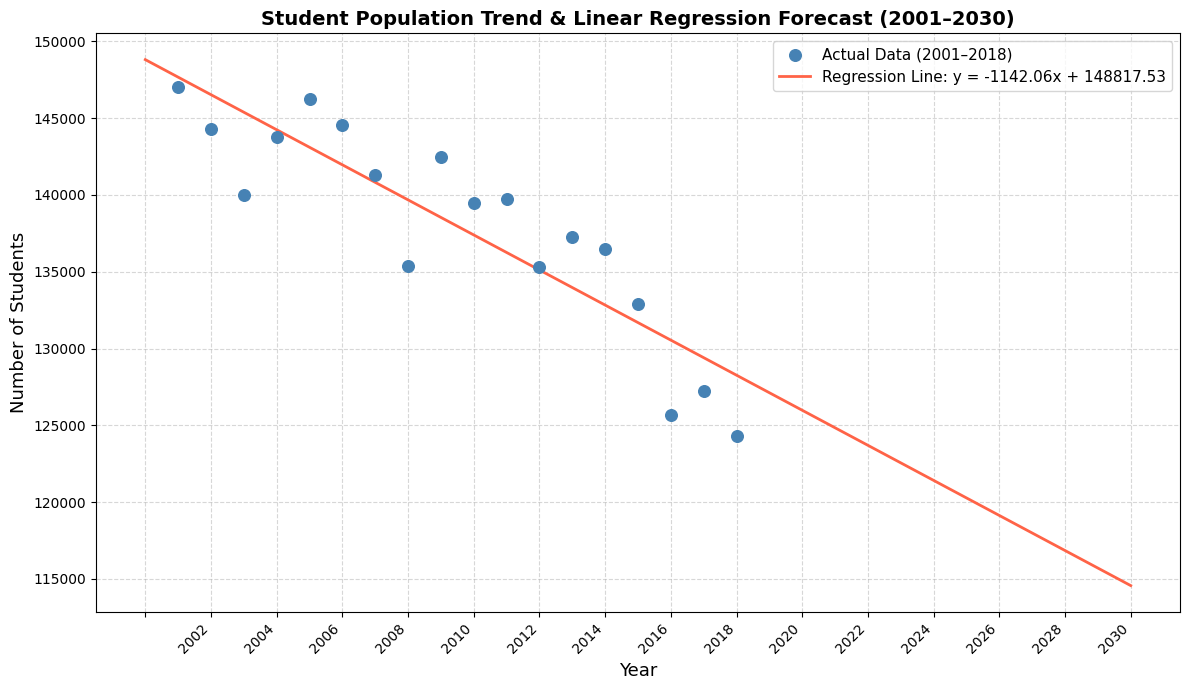

In [ ]:
plot.figure(figsize=(12, 7))
# Scatter plot of actual data
plot.scatter(x, y, color='steelblue', s=70, zorder=5, label='Actual Data (2001–2018)')
# Regression line from x=0 to x=30
plot.plot([0, 30], [b, 30 * a + b], color='tomato', linewidth=2, label=f'Regression Line: y = {a:.2f}x + {b:.2f}')
# X-axis: show calendar years
xtick_positions = list(range(0, 31, 2))
xtick_labels = ['' if i == 0 else str(2000 + i) for i in xtick_positions]
plot.xticks(xtick_positions, xtick_labels, rotation=45, ha='right')
plot.xlabel('Year', fontsize=13)
plot.ylabel('Number of Students', fontsize=13)
plot.title('Student Population Trend & Linear Regression Forecast (2001–2030)', fontsize=14, fontweight='bold')
plot.legend(fontsize=11)
plot.grid(True, linestyle='--', alpha=0.5)
plot.tight_layout()
plot.show()

## Step 6: Predict Future Population

Using the regression equation **y = a·x + b**, we can predict the student population for future years (2019–2030), corresponding to x = 19–30.

In [6]:
future_x = np.array(range(19, 31))
future_years = list(range(2019, 2031))
future_y = a * future_x + b

predictions = pd.DataFrame({
    'Year': future_years,
    'x (encoded)': future_x,
    'Predicted Population': future_y.astype(int)
})

print(predictions.to_string(index=False))

 Year  x (encoded)  Predicted Population
 2019           19                127118
 2020           20                125976
 2021           21                124834
 2022           22                123692
 2023           23                122550
 2024           24                121408
 2025           25                120266
 2026           26                119124
 2027           27                117982
 2028           28                116839
 2029           29                115697
 2030           30                114555


## Step 7: Plot Actual vs. Predicted Population

We overlay the **actual data** (2001–2018) with the **predicted values** (2019–2030) on a single chart to visualize the full trend.

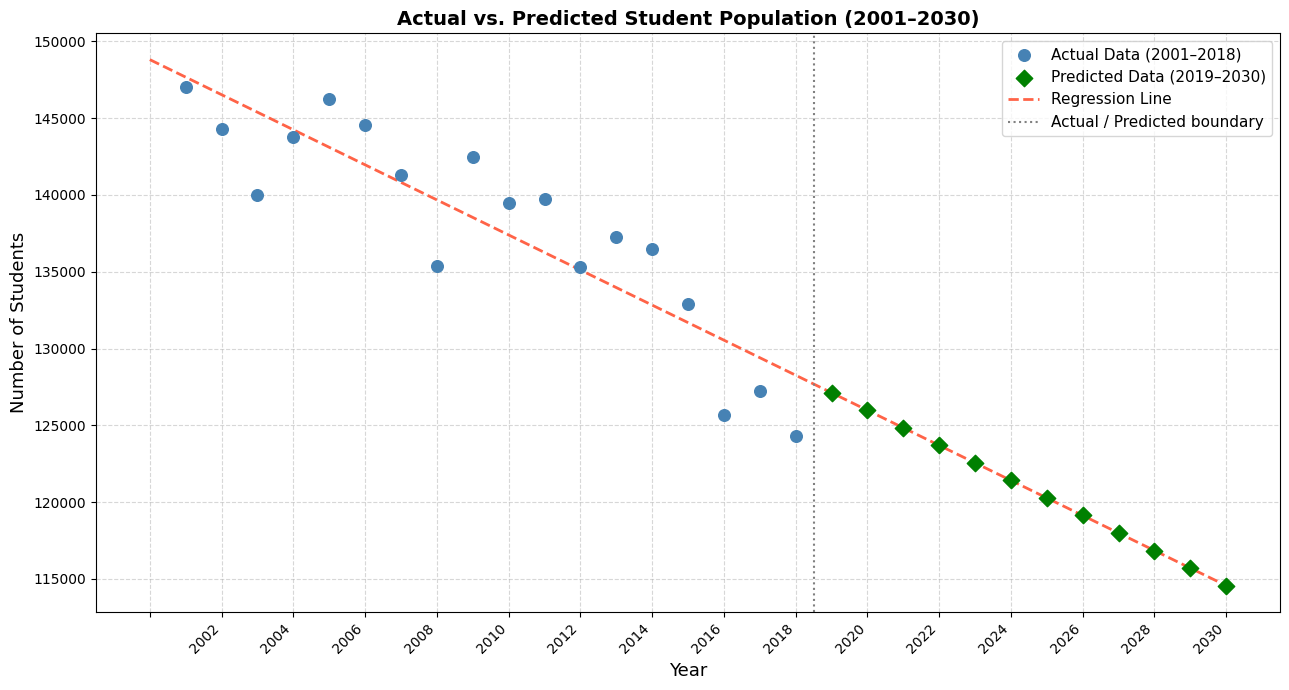

In [ ]:
plot.figure(figsize=(13, 7))
# Actual data
plot.scatter(x, y, color='steelblue', s=70, zorder=5, label='Actual Data (2001–2018)')
# Predicted data
plot.scatter(future_x, future_y, color='green', s=70, marker='D', zorder=5, label='Predicted Data (2019–2030)')
# Regression line
plot.plot([0, 30], [b, 30 * a + b], color='tomato', linewidth=2, linestyle='--', label='Regression Line')
# Dividing line between actual and predicted
plot.axvline(x=18.5, color='gray', linestyle=':', linewidth=1.5, label='Actual / Predicted boundary')
xtick_positions = list(range(0, 31, 2))
xtick_labels = ['' if i == 0 else str(2000 + i) for i in xtick_positions]
plot.xticks(xtick_positions, xtick_labels, rotation=45, ha='right')
plot.xlabel('Year', fontsize=13)
plot.ylabel('Number of Students', fontsize=13)
plot.title('Actual vs. Predicted Student Population (2001–2030)', fontsize=14, fontweight='bold')
plot.legend(fontsize=11)
plot.grid(True, linestyle='--', alpha=0.5)
plot.tight_layout()
plot.show()

## Step 8: Interpretation and Conclusions

The linear regression model produces the following equation:

> **y = −1142.06·x + 148,817.53**

### Key Findings:

| Metric | Value |
|--------|-------|
| Slope (a) | −1,142.06 |
| Intercept (b) | 148,817.53 |
| Population in 2001 | 147,026 |
| Population in 2018 | 124,275 |
| Predicted 2025 | ~120,266 |
| Predicted 2030 | ~114,556 |

### Interpretation:
- The **negative slope (−1,142)** indicates that the student population **declines by approximately 1,142 students per year**.
- Over 18 years (2001–2018), the population dropped from **147,026 to 124,275** — a total decrease of **22,751 students**.
- If this trend continues, the model predicts the population will fall to approximately **114,556 by 2030**.
- The linear model fits the overall downward trend well, though there are some fluctuations (e.g., slight upticks in 2005 and 2009).